<a href="https://colab.research.google.com/github/jcumbicosr/sistemas-fotovoltaicos/blob/main/Modelagem_com_PVlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistemas Fotovoltaicos On-Grid e Off-Grid


**Work Proposal**

The objective of this work is to model a photovoltaic (PV) power plant chosen by the user, considering an inverter with a power rating equal to or greater than 75 kW and a set of PV modules whose total power exceeds that of the inverter. The modeling will be carried out using the Python programming language and the PVlib library, and also consider data from PVsyst for comparison purposes. It is not necessary to allocate the inverter's inputs and MPPT, only to account for its losses and power.

#### Install and import libraries

In [ ]:
! pip install -qU pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 91.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import pvlib
import matplotlib.pyplot as plt
import folium
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Modeling of the Photovoltaic Plant

This work models a 125 kW grid-connected photovoltaic (PV) power plant located in Brasilia, Brazil. The model considers the performance characteristics of selected PV modules and an inverter.


Subsequent sections detail the specifications of the chosen PV module and inverter.


In [ ]:
# @title Choose the module

modules = pvlib.pvsystem.retrieve_sam('CECMod').T
# Filter modules by STC and I_sc_ref
modules = modules[(modules['STC'] > 420) & (modules['I_sc_ref'] > 8)]

module = modules.iloc[2]
module = pd.DataFrame(module).T

print("Module details:")
display(module.T)


Module details:


,Canadian_Solar_Inc__CS1U_430MS
Technology,Mono-c-Si
Bifacial,0
STC,430.803
PTC,402.1
A_c,1.99
Length,NaN
Width,NaN
N_s,81
I_sc_ref,9.9
V_oc_ref,54.0


Now, we calculate the number of panels considering a factor of 20% more than the inverter capacity. This approach accounts for the fact that PV modules rarely operate at their rated capacity due to real-world conditions such as: temperature losses, irradiance variability and system losses, soiling, shading, and mismatch losses between modules.

In [ ]:
#@title Define the PV power plant in kW:

pv_power_system = 125 # @param {"type":"number"}
dc2ac_ratio = 1.20 # @param {"type":"number"}


panel_capacity = module['STC'].values[0]


print(f'DC-to-AC ratio: {dc2ac_ratio}')
print(f"PV power system: {pv_power_system} kW")
print(f"Module capacity: {panel_capacity:.2f} W")
print()

dc_capacity = pv_power_system * dc2ac_ratio
print(f"DC capacity: {dc_capacity:.2f} kW")

number_modules = round(dc_capacity / (panel_capacity/1000.0))
print(f"Number of modules: {number_modules}")


DC-to-AC ratio: 1.2
PV power system: 125 kW
Module capacity: 430.80 W

DC capacity: 150.00 kW
Number of modules: 348


In [ ]:
# @title Choosing the inverter

inverters = pvlib.pvsystem.retrieve_sam('SandiaInverter').T

# Filter by capacity and maximum voltage input
inverters = inverters[(inverters['Vdcmax'] >= 1000) &
                       (inverters['Paco'] >=(pv_power_system*1000))]
inverters = inverters.sort_values(by='Paco', ascending=True)

inverter = inverters.iloc[3]
inverter = pd.DataFrame(inverter).T

print("Inverter details:")
display(inverter.T)

Inverter details:


,Sungrow_Power_Supply_Co___Ltd___SG125HV__600V_
Vac,600
Pso,96.387039
Paco,125178.0
Pdco,127596.132813
Vdco,945.0
C0,-0.0
C1,0.000018
C2,0.004265
C3,0.002505
Pnt,37.5534


In [ ]:
#@title Defining the modules in series-parallel

modules_in_series = 25 # @param {"type":"integer"}
modules_in_parallel = 14 # @param {"type":"integer"}

inverter_capacity = inverter['Paco'].values[0] / 1000
print(f"Inverter capacity: {inverter_capacity:.2f} kW")
print(f"Number of modules to configure: {number_modules}")
print()

# Check with datasheet of inverter
v_modules_serie = module['V_mp_ref'].values[0] * modules_in_series
i_modules_paralelo = module['I_mp_ref'].values[0] * modules_in_parallel
v_inverter_low  = inverter['Mppt_low'].values[0]
v_inverter_high = inverter['Mppt_high'].values[0]
i_inverter_max = inverter['Idcmax'].values[0]

# Check voltage
v_ok = v_inverter_low <= v_modules_serie <= v_inverter_high
if v_ok:
  print(f"Voltage in series OK: {v_inverter_low} V <= {v_modules_serie} V <= {v_inverter_high}")
else:
    raise ValueError(f"Voltage in series not OK: {v_inverter_low} V <= {v_modules_serie} V <= {v_inverter_high}")

# Check current
i_ok = i_inverter_max >= i_modules_paralelo
if i_ok:
  print(f"Current in parallel OK: {i_modules_paralelo} A <= {i_inverter_max} A\n")
else:
    raise ValueError(f"Current in parallel not OK: {i_modules_paralelo} A <= {i_inverter_max} A")

modules_per_array = modules_in_series * modules_in_parallel
print(f"Number of modules per array: {modules_per_array}")


# Check if the configuration is equal to total number of modules
number_arrays = number_modules // modules_per_array
number_arrays = 1 if number_arrays == 0 else number_arrays
total_modules = number_arrays * modules_per_array

if number_modules == total_modules:
    print(f"All modules are allocated")
else:
    print(f"Number of arrays: {number_arrays}")
    print(f"Number of modules not allocated: {number_modules - total_modules}")
    print(f"Total number of modules: {total_modules}")






Inverter capacity: 125.18 kW
Number of modules to configure: 348

Voltage in series OK: 860.0 V <= 1132.5 V <= 1200.0
Current in parallel OK: 133.14 A <= 135.022363 A

Number of modules per array: 350
Number of arrays: 1
Number of modules not allocated: -2
Total number of modules: 350


In [ ]:
#@title Defining the location

latitude = -15.788333  # @param {"type":"number"}
longitude = -47.713774  # @param {"type":"number"}
altitude = 1023 # @param {"type":"number"}
timezone = "America/Sao_Paulo" # @param {"type":"string"}
name_location = 'Brasilia'  # @param {"type":"string"}
year = 2023 # @param {"type":"integer"}

# Create location object to store lat, lon, timezone
site_location = pvlib.location.Location(latitude, longitude, altitude=altitude,
                                        tz=timezone, name=name_location)

map_object = folium.Map(location=[latitude, longitude], zoom_start=11)

# # Create the marker with the pin icon
marker = folium.Marker([latitude, longitude])
marker.add_to(map_object)

# Add the location name as a label next to the marker
folium.Marker(
    [latitude, longitude],
    icon=folium.DivIcon(
        icon_size=(150,36),
        icon_anchor=(7,20),
        html='<div style="font-size: 12pt; color : black; padding-left: 20px;">'+name_location+'</div>',
    )
).add_to(map_object)

# Display the map
map_object

## Data for modeling

We download the data from [PVGIS](https://re.jrc.ec.europa.eu/pvg_tools/en/). It is a web application that allows to get data on solar radiation at any place in most parts of the world. We use [get_pvgis_hourly](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_pvgis_hourly.html) fuction available in pvlib library  to download the data on horizontal plane.

The output data includes the following fields:

| Variable                   | Type  | Description                                             |
|---------------------------|-------|---------------------------------------------------------|                      
| poa_global         | float | Global irradiance on inclined plane (W/m²)              |
| poa_direct        | float | Beam (direct) irradiance on inclined plane (W/m²)       |
| poa_sky_diffuse   | float | Diffuse irradiance on inclined plane (W/m²)             |
| poa_ground_diffuse| float | Reflected irradiance on inclined plane (W/m²)           |
| solar_elevation    | float | Sun height/elevation (degrees)                          |
| temp_air             | float | Air temperature at 2 m (degrees Celsius)                |
| wind_speed         | float | Wind speed at 10 m (m/s)                                |
| Int                       | int   | Solar radiation reconstructed (1/0)                     |



,DNI,DHI,poa_ground_diffuse,solar_elevation,temp_air,wind_speed,Int,GHI
time,,,,,,,,
2023-01-01 00:04:00-03:00,0.0,0.0,0.0,0.0,19.92,1.59,0,0.0
2023-01-01 01:04:00-03:00,0.0,0.0,0.0,0.0,19.57,1.24,0,0.0
2023-01-01 02:04:00-03:00,0.0,0.0,0.0,0.0,19.32,1.03,0,0.0
2023-01-01 03:04:00-03:00,0.0,0.0,0.0,0.0,18.72,1.03,0,0.0
2023-01-01 04:04:00-03:00,0.0,0.0,0.0,0.0,18.91,1.10,0,0.0


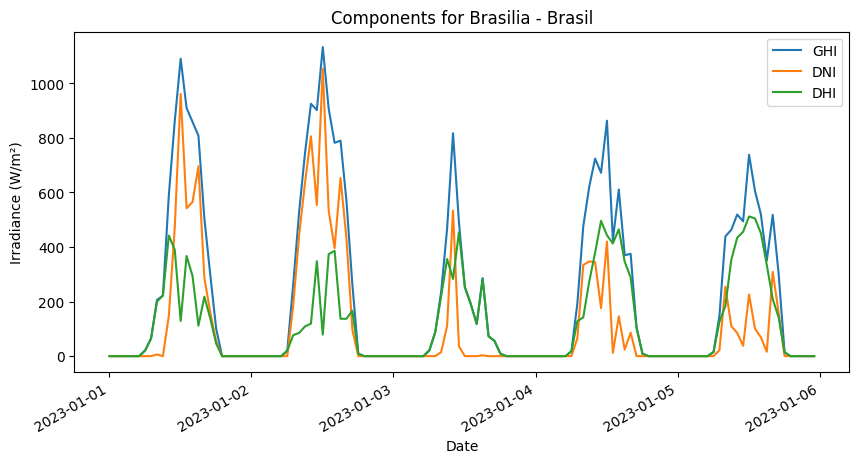

In [ ]:
#@title Downloading data from PVGIS

# Download solar components
df_data, _, _ = pvlib.iotools.get_pvgis_hourly(latitude, longitude, year)

# Calculate the GHI as the sum of components
df_data['GHI'] = df_data['poa_direct'] + \
                 df_data['poa_sky_diffuse'] + \
                 df_data['poa_ground_diffuse']

# Rename the cols
renames_cols = {
    'poa_direct': 'DNI',
    'poa_sky_diffuse': 'DHI'
}
df_data = df_data.rename(columns=renames_cols)

# Set timezone
df_data.index = df_data.index.tz_convert(timezone)

# Filter the data for the year
df_data = df_data[df_data.index.year == year]

# Print samples of the data
display(df_data.head())

# Plot the data
df_data.loc['2023-01-01':'2023-01-05', ['GHI', 'DNI', 'DHI']].plot(figsize=(10, 5), title='Components for Brasilia - Brasil')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Date')

plt.show()


## Plane of Array (POA)

POA irradiance refers to the total solar radiation received by the surface of the PV modules, which are often tilted at an angle to optimize energy capture. It is typically composed of three components:

* **Direct irradiance (DNI)**: Solar radiation received directly from the sun.

* **Diffuse irradiance (DHI)**: Solar radiation scattered by the atmosphere and clouds.

* **Ground-reflected irradiance**: Solar radiation reflected from the ground surface.

The equation is given by:

$$ I_{POA} = I_{direct} + I_{diffuse} + I_{ground}$$

In this work, we use the **Perez-Driesse model** for estimate POA irradiance on solar panels or other arbitrarily oriented surfaces. It is a variant of the well-known Perez transposition model with updates based on more recent research to improve accuracy and applicability, especially for modern photovoltaic (PV) applications.

The Perez model is an anisotropic sky modeling approach that accounts for circumsolar brightening (enhanced irradiance near the sun) and horizon/zenith brightening (variations near the horizon or zenith). However, the model uses discrete bins for Sky clearness ($ϵ$), causing abrupt jumps in predictions when $ϵ$ crosses bin boundaries. This limitation is addressed in the Perez-Driesse model, where the authors replace the lookup table with six quadratic splines, ensuring smooth transitions between ϵ values.

To estimate the solar radiation received on the surface of a PV module is essential to consider the module’s tilt inclination and azimuth angles. For inclination angle, we use the next table develop by Villalva in 2007 to optimize the average annual irradiance capture

To estimate the solar radiation received on the surface of PV module, it is essential to consider both the tilt (inclination) and azimuth angles of the module. For determining the optimal tilt angle, we adopt the guideline proposed by Villalva (2007), which aims to maximize the average annual irradiance captured by the PV system based on the site's latitude.


| Latitude       | Inclination (β)         |
|----------------|-----------------------------------|
| 0° a 10°       | β = 10°                           |
| 11° a 20°      | β = latitude                      |
| 21° a 30°      | β = latitude + 5°                 |
| 31° a 40°      | β = latitude + 10°                |
| 41° ou mais    | β = latitude + 15°                |

Given the latitude −15.788333° (south of the equator), we refer to the table:

The latitude falls in the range 11° to 20°, so:

$$𝛽 =∣latitude∣=15.788^o$$

For southern hemisphere, PV modules should generally face true north, so the azimuth angle is:

$$Azimuth = 0^o$$

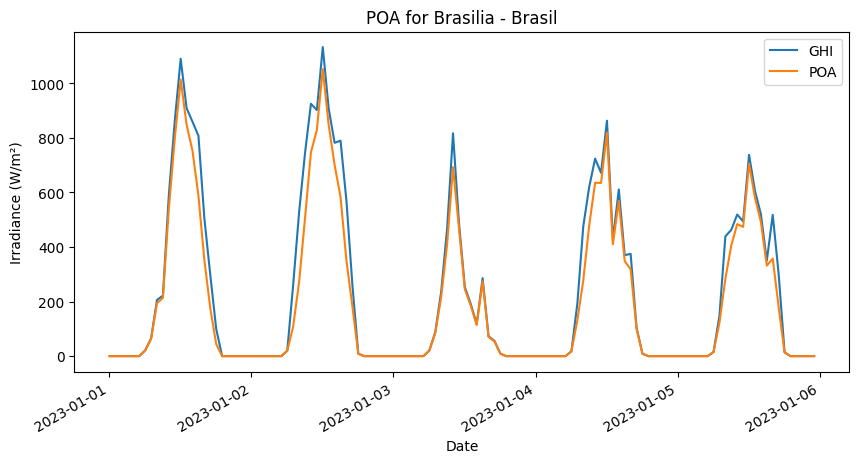

In [ ]:
#@title Calculating  POA irradiance

inclination = 15.788 # @param {"type":"number"}
azimuth = 0  # @param {"type":"number"}

# Calculate clear-sky GHI and transpose to plane of array
def get_poa_irradiance(location, times, dni, ghi, dhi, tilt, azimuth, model = "perez-driesse"):

    # Get solar azimuth and zenith to pass to the transposition function
    solar_position = location.get_solarposition(times=times)
    # Get the extrarrestrial radiation
    extra_solar = pvlib.irradiance.get_extra_radiation(times)
    # Use the get_total_irradiance function to transpose the GHI to POA
    POA_irradiance = pvlib.irradiance.get_total_irradiance(
        surface_tilt = tilt,
        surface_azimuth = azimuth,
        dni = dni,
        ghi = ghi,
        dhi = dhi,
        dni_extra = extra_solar,
        solar_zenith = solar_position['apparent_zenith'],
        solar_azimuth = solar_position['azimuth'],
        model = model)

    # Return DataFrame with only GHI and POA
    return pd.DataFrame({'GHI': ghi,
                         'POA': POA_irradiance['poa_global']})


df_poa = get_poa_irradiance(location = site_location,
                            times = df_data.index,
                            dni = df_data['DNI'],
                            ghi = df_data['GHI'],
                            dhi = df_data['DHI'],
                            tilt = inclination,
                            azimuth = azimuth)

# Print samples of the data
#display(df_poa.head())

# Plot the data
df_poa.loc['2023-01-01':'2023-01-05', ['GHI', 'POA']].plot(figsize=(10, 5), title='POA for Brasilia - Brasil')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Date')

plt.show()


## **Monthly power generation**

To estimate the energy generation of PV system, we use the Single Diode Model (SDM). This model includes five key parameters and allows for accurate simulation of PV module performance under various environmental conditions (irradiance and temperature).

The output current $I$ is given by the following equation:

$$
I = I_L - I_0 \left( \exp\left( \frac{V + I R_s}{n V_t} \right) - 1 \right) - \frac{V + I R_s}{R_p}
$$

Where:

* $I$ is the output current (A),
* $V$ is the output voltage (V),
* $I_L$ is the photogenerated current (A),
* $I_0$ is the diode saturation current (A),
* $R_s$ is the series resistance ($\Omega$),
* $R_p$ is the shunt resistance ($\Omega$),
* $n$ is the diode ideality factor,
* $V_t = \frac{kT}{q}$ is the thermal voltage (V),
* $k$ is Boltzmann's constant ($1.38 \times 10^{-23}\,\text{J/K}$),
* $T$ is the cell temperature (K),
* $q$ is the elementary charge ($1.602 \times 10^{-19}\,\text{C}$).



### Calculating the parameters for the De Soto model

To use the SDM, we need to extract the five parameters. We use the De Soto Method to estimate the parameters based on the module’s standard test conditions (STC) and adjusts them for real operating conditions using temperature and irradiance models. It is accurate and physically grounded. This method provide estimates for:

* Series resistance $R_s$
* Shunt resistance $R_p$
* Photogenerated current $I_L$
* Saturation current $I_0$
* Diode ideality factor $a_0$

In [ ]:
#@title Fitting the parameters

# Get parameters from the module
v_mp = module['V_mp_ref'].values[0]
i_mp = module['I_mp_ref'].values[0]
v_oc = module['V_oc_ref'].values[0]
i_sc = module['I_sc_ref'].values[0]
alpha_sc = module['alpha_sc'].values[0]
beta_voc = module['beta_oc'].values[0]
cells_in_series = module['N_s'].values[0]


def fit_desoto_params(v_mp, i_mp, v_oc, i_sc, alpha_sc, beta_voc, cells_in_series):
    desoto_fit_params  = pvlib.ivtools.sdm.fit_desoto(v_mp,
                                                    i_mp,
                                                    v_oc,
                                                    i_sc,
                                                    alpha_sc,
                                                    beta_voc,
                                                    cells_in_series,
                                                    root_kwargs = {'method': 'lm', 'options':{'maxiter':10000, 'xtol': 1e-3, 'gtol': 1e-3}})

    params = desoto_fit_params[0]
    dict_params = {
        'I_L': params['I_L_ref'],
        'I_0': params['I_o_ref'],
        'R_s': params['R_s'],
        'R_p': params['R_sh_ref'],
        'a_0': params['a_ref']
    }

    # Return dataframe
    return pd.DataFrame(dict_params, index=[0])

df_params = fit_desoto_params(v_mp, i_mp, v_oc, i_sc, alpha_sc, beta_voc, cells_in_series)

# Print samples of the data
print("Parameters for the De Soto model:")
display(df_params)


Parameters for the De Soto model:


,I_L,I_0,R_s,R_p,a_0
0,9.923725,1.168451e-11,0.269414,5.690665e+10,1.965926


###  Solve SDM equation

The previously calculated parameters are used to solve SDM equation at five key points on the I-V curve of a PV module, typically corresponding to the following current and voltage values:

* Open-Circuit Voltage ($V_{oc}$)
* Short-Circuit Current ($I_{sc}$)
* Maximum Power Point (MPP): $V_{mp}$, $I_{mp}$
* Voltage at zero power ($V=0$) (i.e., short-circuit condition)
* Current at zero power ($i=0$) (i.e., open-circuit condition)

But since the SDM equation is implicit in $I$, we can’t solve it analytically. Instead, we use numerical methods (like Newton-Raphson or Lambert W function) or libraries like pvlib. We will compute the five points using pvlib.pvsystem.singlediode function, which solves the SDM numerically.

In [ ]:
#@title Solve the equation

# Irradiance in STC conditions (1000 W/m² e 25°C)
irrad = 1000
temp_cell = 25

a_ref = df_params['a_0'][0]
I_L_ref = df_params['I_L'][0]
I_o_ref = df_params['I_0'][0]
R_sh_ref = df_params['R_p'][0]
R_s = df_params['R_s'][0]
method = 'lambertw'
number_of_points = 100

# Solve the equation
def solve_desoto_params(irrad, temp_cell, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points):

    diode_params_desoto = pvlib.pvsystem.calcparams_desoto(irrad, temp_cell, alpha_sc, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s)
    SDE_params = {
            'photocurrent': diode_params_desoto[0],
            'saturation_current': diode_params_desoto[1],
            'resistance_series': diode_params_desoto[2],
            'resistance_shunt': diode_params_desoto[3],
            'nNsVth': diode_params_desoto[4]
        }

    curve_info = pvlib.pvsystem.singlediode(method=method, **SDE_params)
    v = pd.DataFrame(np.linspace(0, curve_info['v_oc'], number_of_points))
    i = pd.DataFrame(pvlib.pvsystem.i_from_v(voltage=v, method=method, **SDE_params))

    return {
        'Key_points': curve_info,
        'Voltage': v,
        'Current': i
        }


results = solve_desoto_params(irrad, temp_cell, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)
print('Key point of curve IV:')
for key, value in results['Key_points'].items():
    print(f"{key}: {value:.3f}")



Key point of curve IV:
i_sc: 9.924
v_oc: 53.999
i_mp: 9.487
v_mp: 45.301
p_mp: 429.791
i_x: 9.924
i_xx: 7.064


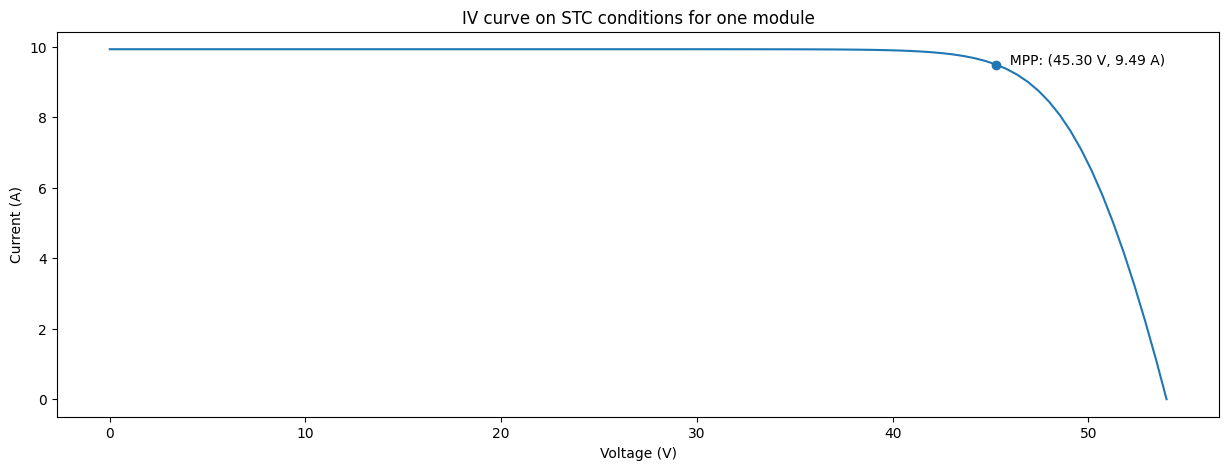

In [ ]:
#@title IV curve plot

def plot_curve_iv(results, title):
    plt.figure(figsize=(15, 5))
    plt.plot(results['Voltage'], results['Current'])
    plt.scatter(results['Key_points']['v_mp'], results['Key_points']['i_mp'])
    plt.title(title)
    plt.xlabel('Voltage (V)')
    plt.ylabel('Current (A)')
    # Add annotation of mpp, specifying xy coordinates
    plt.annotate(f'  MPP: ({results["Key_points"]["v_mp"]:.2f} V, {results["Key_points"]["i_mp"]:.2f} A)',
                 xy=(results['Key_points']['v_mp'] + 0.25, results['Key_points']['i_mp']))

    plt.show()

plot_curve_iv(results, 'IV curve on STC conditions for one module')

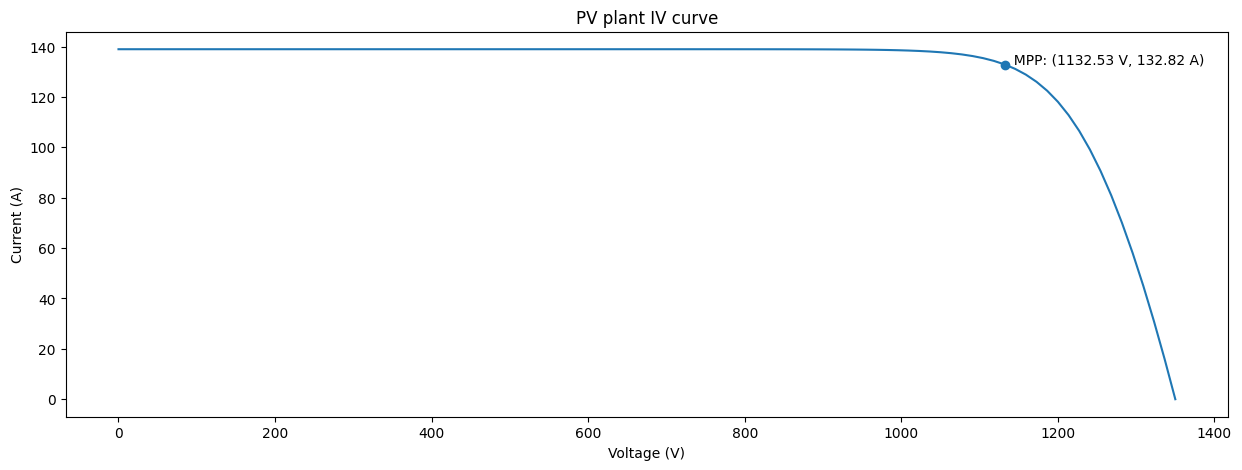

In [ ]:
#@title PV plant IV curve

# a_ref = df_params['a_0'][0] * modules_serie
# I_L_ref = df_params['I_L'][0] * modules_paralelo
# I_o_ref = df_params['I_0'][0] * modules_paralelo
# R_sh_ref = df_params['R_p'][0] * (modules_serie/modules_paralelo)
# R_s = df_params['R_s'][0] * (modules_serie/modules_paralelo)

a_ref = df_params['a_0'][0] * modules_in_series  # Stays the same (series voltage adds)
I_L_ref = df_params['I_L'][0] * modules_in_parallel * number_arrays  # Current multiplies by parallel strings
I_o_ref = df_params['I_0'][0] * modules_in_parallel * number_arrays  # Same as I_L_ref
R_sh_ref = df_params['R_p'][0] * (modules_in_series/modules_in_parallel) / number_arrays  # Parallel resistances divide
R_s = df_params['R_s'][0] * (modules_in_series/modules_in_parallel) / number_arrays  # Series resistances divide

results = solve_desoto_params(irrad, temp_cell, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)

plot_curve_iv(results, 'PV plant IV curve')
#

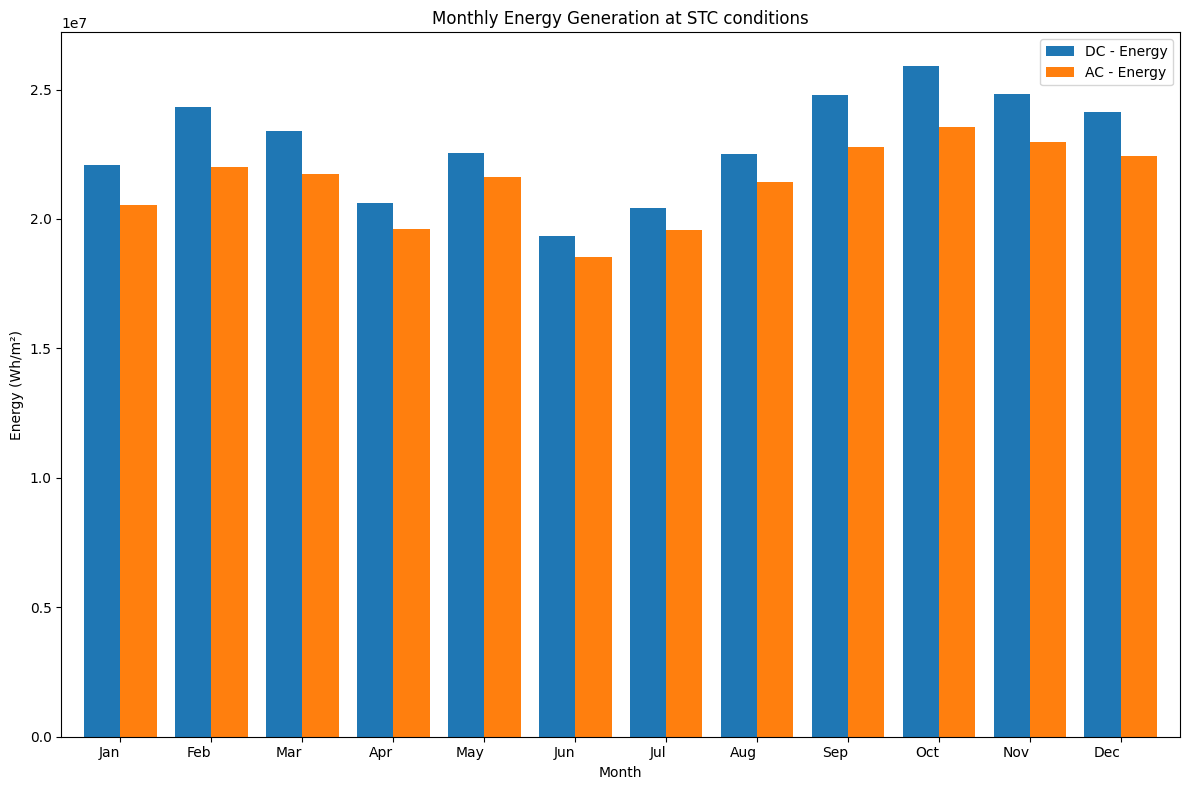

In [ ]:
#@title Monthly generation

df_dc_power = pd.DataFrame()
df_ac_power = pd.DataFrame()

poa_2_power = solve_desoto_params(df_poa['POA'], temp_cell, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)

# Get the energy
df_dc_power['STC conditions'] = poa_2_power['Key_points']['p_mp']

# Calculate AC energy
df_ac_power = pvlib.inverter.pvwatts(df_dc_power['STC conditions'],
                                     inverter['Pdco'].values[0],
                                     eta_inv_nom=0.96)

# Calculate the monthly energy
df_monthly_dc_energy = pd.DataFrame()
df_monthly_ac_energy = pd.DataFrame()
df_monthly_dc_energy['STC conditions'] = df_dc_power['STC conditions'].resample('ME').sum()
df_monthly_ac_energy['STC conditions'] = df_ac_power.resample('ME').sum()

df_plot_energy = pd.DataFrame()
df_plot_energy['DC - Energy'] = df_monthly_dc_energy['STC conditions']
df_plot_energy['AC - Energy'] = df_monthly_ac_energy['STC conditions']

def plot_monthly_energy(df_plot_energy, title):
    # Plot
    df_plot_energy.plot(kind='bar', figsize=(12, 8), width=0.8)
    plt.title(title)
    plt.ylabel('Energy (Wh/m²)')
    plt.xlabel('Month')
    #plt.xticks(rotation=45, ha='right')

    # Get the month names from the index
    month_names = df_plot_energy.index.strftime('%b') # '%b' gives abbreviated month name

    # Set the x-tick labels to the month names
    plt.xticks(ticks=range(len(month_names)), labels=month_names, rotation=0, ha='right')


    plt.legend()
    plt.tight_layout()
    plt.show()

plot_monthly_energy(df_plot_energy, 'Monthly Energy Generation at STC conditions')


## Performance analysis

### Yield

The final yield (Yf) reflects the total amount of energy delivered to the grid or load per kilowatt of installed capacity. The final yield normalizes production, allowing for meaningful comparisons between systems of different scales or in different locations. This metric is especially useful for evaluating the long-term performance and efficiency of a PV installation, identifying potential issues such as shading, equipment faults, or soiling, and estimating energy generation for financial planning.

Yearly final yield (Yf): 1703.197



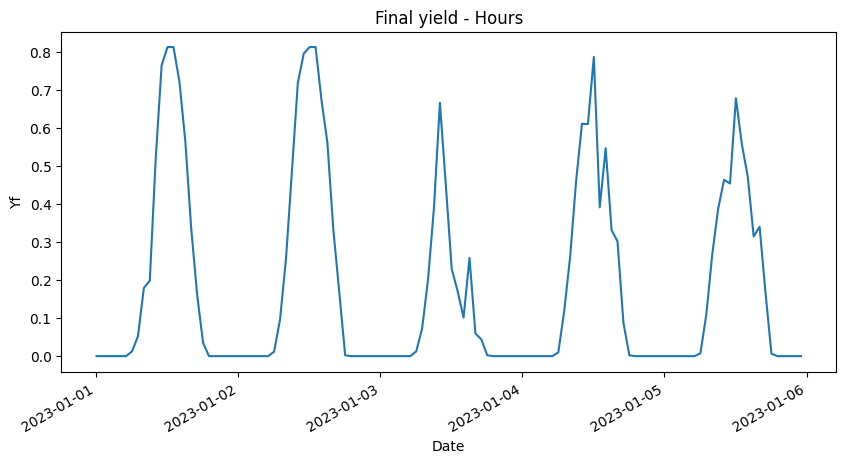

In [ ]:
#@title Calculating the Yf

Yf = df_ac_power / (v_mp * i_mp * total_modules)

year_yf = df_ac_power.sum() / (v_mp * i_mp * total_modules)
print(f"Yearly final yield (Yf): {year_yf:.3f}")
print()

# Plot
Yf.iloc[:5*24].plot(figsize=(10, 5), title='Final yield - Hours')
plt.ylabel('Yf')
plt.xlabel('Date')
plt.show()


The Reference Yield (Yr) represents the total in-plane solar irradiance (i.e., irradiance on the PV plane) received over a period, normalized by the standard irradiance of 1,000 W/m²

In [ ]:
#@title Calculating the Yr

Yr = df_poa['POA'] / 1000

year_yr = df_poa['POA'].sum() / 1000
print(f"Yearly reference yield (Yr): {year_yr:.3f}")
print()

Yearly reference yield (Yr): 1835.255



### Performance Ratio (PR)

PR is a key metric used to evaluate the efficiency and quality of PV system. It indicates how effectively the system converts the available solar energy into usable electricity.

What PR Represents:
* A PR of 100% means the system is performing at its theoretical maximum, which is not possible due to real-world losses.

* A typical PR for a well-designed and maintained PV system ranges from 75% to 90%.

Yearly performance Ratio (PR): 92.804



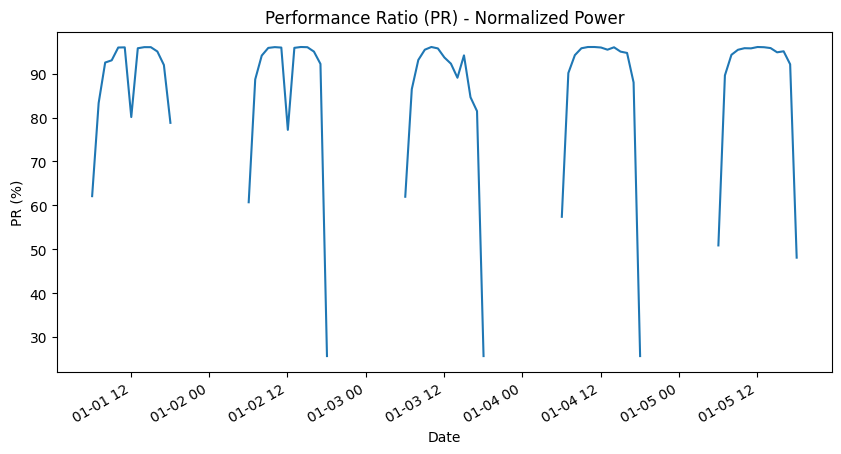

In [ ]:
#@title Calculating the PR

#poa_2_power = solve_desoto_params(df_poa['POA'], temp_cell, a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)

# Get the energy
#Energy = poa_2_power['Key_points']['p_mp'] / 1 # To convert Wh/m2

# POA peak sun hours
#poa_peak = df_poa['POA'] / 1000 * v_mp * i_mp * total_modules

# Calculate PR
PR = Yf / Yr * 100

year_pr = Yf.sum() / Yr.sum() * 100
print(f"Yearly performance Ratio (PR): {year_pr:.3f}")
print()

# Plot
PR.iloc[:5*24].plot(figsize=(10, 5), title='Performance Ratio (PR) - Normalized Power')
plt.ylabel('PR (%)')
plt.xlabel('Date')
plt.show()


### Capacity factor (CF)

The CF quantifies how intensively a power-generating asset is used by comparing its actual energy output to the theoretical maximum it could have produced if it had operated at its rated power every hour of the evaluation period.

Because photovoltaic plants can only generate when the sun is available—and because output is further reduced by weather, temperature, shading, and system losses—PV capacity factors are much lower than those of conventional thermal plants, typically ranging from 15 % to 25 % on an annual basis in most regions (and up to ~30 % in the world’s best desert sites).

Yearly capacity factor (CF): 19.450



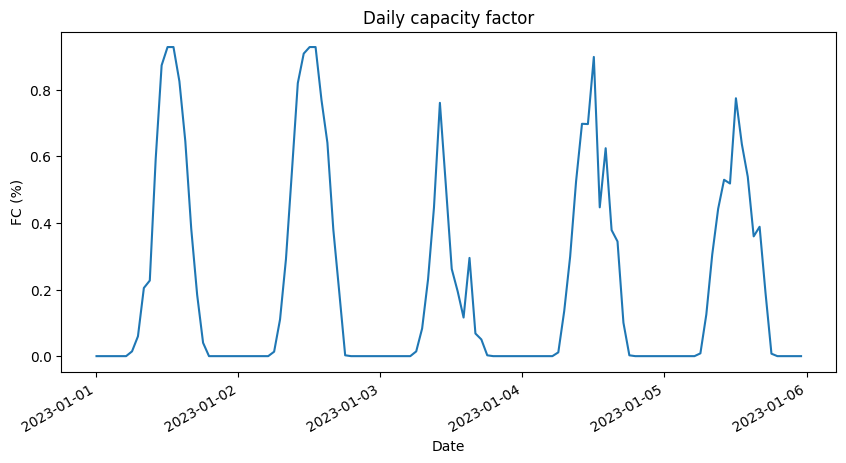

In [ ]:
#@title Calculating the CF

num_horas = len(df_ac_power)
FC = df_ac_power / (v_mp * i_mp * total_modules * num_horas) * 100
year_fc = FC.sum()

print(f"Yearly capacity factor (CF): {year_fc:.3f}")
print()

# Plot
# Plot
FC1=FC*100
FC1.iloc[:5*24].plot(figsize=(10, 5), title='Daily capacity factor')
plt.ylabel('FC (%)')
plt.xlabel('Date')
plt.show()

## Comparison with simulated data (PVsyst)

In the absence of actual generation data, PVsyst was used to simulate the required data. The simulation utilized the same tilt and azimuth values as the POA calculation. The simulation incorporated thermal losses, soiling losses, unavailability of the system losses, ohmic losses, and mismatch losses.

The PVsyst simulation data and report can be downloaded via the following [link](https://drive.google.com/drive/folders/1KAtWUDlsW2ge6yIviHC-sozBxTZCllgz?usp=sharing). For proper execution of the code below, save the simulation data in the Colab folder first.

In [ ]:
#@title Load simulated data

def load_solar_data(file_path):
    """
    Loads and processes a solar energy CSV file from PVsyst.

    Args:
        file_path (str): Path to the CSV file

    Returns:
        pd.DataFrame: Processed DataFrame with columns:
            - Data (datetime): Date in DD/MM/YYYY format
            - EArray (float): Energy generated by the array
            - EOutInv (float): Energy output from inverter

    Raises:
        ValueError: If file cannot be loaded or parsed
    """

    # Load CSV
    df = pd.read_csv(
        file_path,
        delimiter=';',
        skiprows=11,
        decimal=',',
        encoding='latin-1'
    )

    # Standardize column names
    df.columns = ['time', 'PVsyst - DC', 'PVsyst - AC']

    df = df.iloc[:-1, :]

    df['time'] = pd.to_datetime(df['time'], format='%d/%m/%y')

    # Set the column as the index
    df.set_index(df.columns[0], inplace=True)

    # Validate data
    if df.isnull().values.any():
        raise ValueError("Data contains missing values")

    return df

# Monthly data
file_path = '/content/monthly_data.CSV'

# Load and process data
df_monthly_pvsyst = load_solar_data(file_path)
df_monthly_pvsyst.index = df_monthly_dc_energy.index

# Conver to Wh
df_monthly_pvsyst = df_monthly_pvsyst * 1000

# # Show results
print("Monthly data loaded successfully!")
# display(df_monthly_pvsyst)

Monthly data loaded successfully!


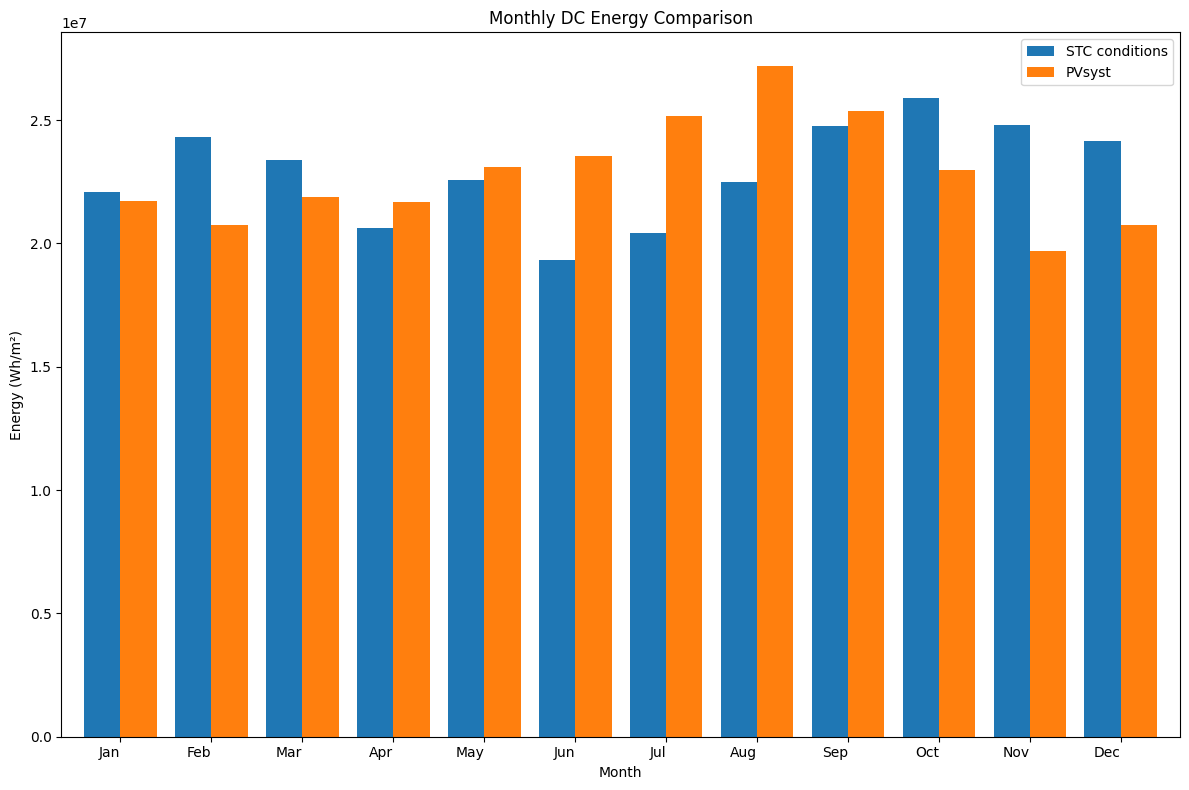

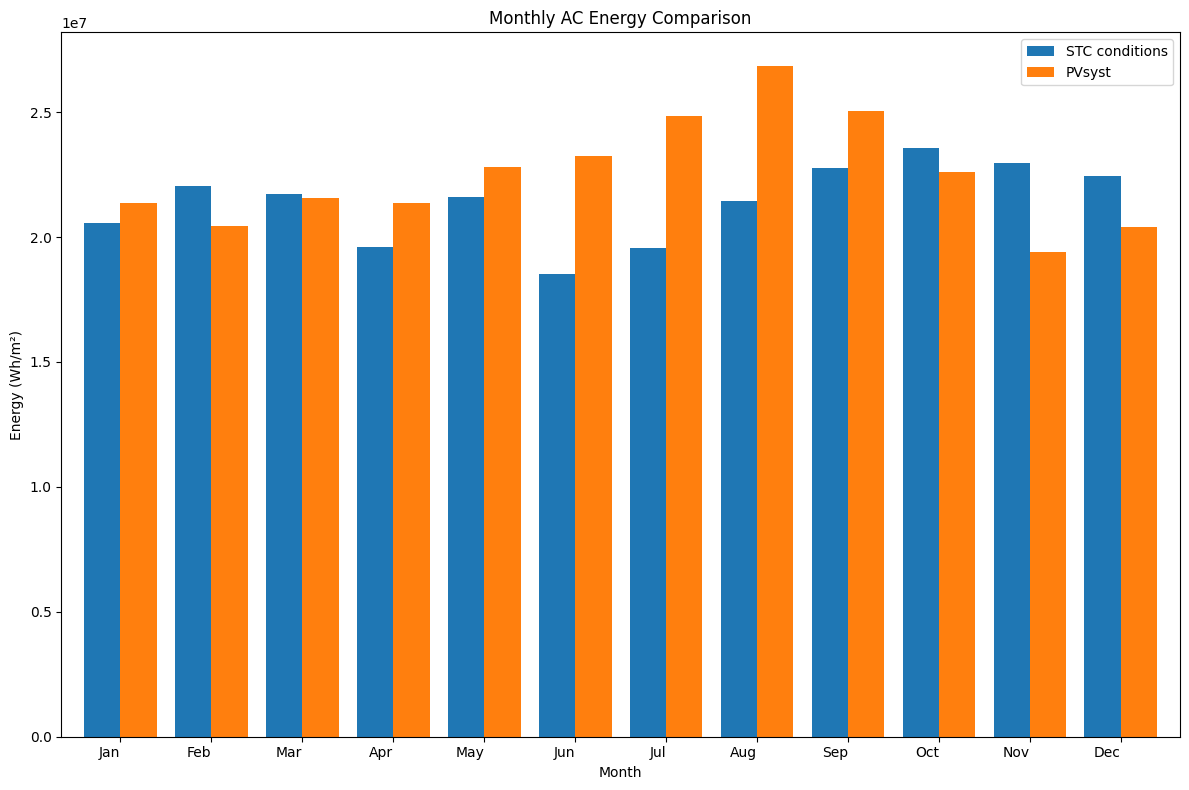

In [ ]:
#@title Comparing the monthly energy
# Create a DataFrame containing both modeled data and PVSyst data

df_monthly_dc_energy['PVsyst'] = df_monthly_pvsyst['PVsyst - DC']
df_monthly_ac_energy['PVsyst'] = df_monthly_pvsyst['PVsyst - AC']

plot_monthly_energy(df_monthly_dc_energy, 'Monthly DC Energy Comparison')
plot_monthly_energy(df_monthly_ac_energy, 'Monthly AC Energy Comparison')







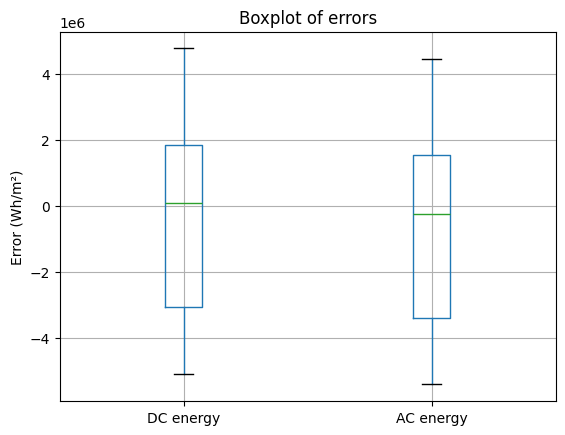

In [ ]:
#@title Boxplot

df_error = pd.DataFrame()
df_error['DC energy'] = df_monthly_dc_energy['PVsyst'] - df_monthly_dc_energy['STC conditions']
df_error['AC energy'] = df_monthly_ac_energy['PVsyst'] - df_monthly_dc_energy['STC conditions']

# Plot df_error
df_error.boxplot()
plt.title('Boxplot of errors')
plt.ylabel('Error (Wh/m²)')
plt.show()

In some months, there are significant differences between the modeled energy and the energy simulated by PVsyst, this variation is represented in error boxplot. The boxplot reveals predominantly positive errors, suggesting systematic overestimation in the modeled data compared to PVsyst simulations. This bias is attributable to PVsyst's incorporation of array and system losses in its calculations. Moreover, the modeling approach utilizes single-year weather data, whereas PVsyst employs TMY (Typical Meteorological Year) data. This fundamental difference in meteorological inputs may also explain the observed variations in results.

# 2. PV Plant Modeling for Different Temperature Models

Among the various environmental factors influencing PV output, cell temperature plays a critical role. The higher cell temperatures can substantially degrade the efficiency of PV modules. This thermal sensitivity, leads to measurable losses in power output, particularly in hot climates.

To accurately estimate the operating temperature of PV modules, pvlib offers several widely used empirical models, each designed to simulate real-world thermal behavior under varying environmental conditions.

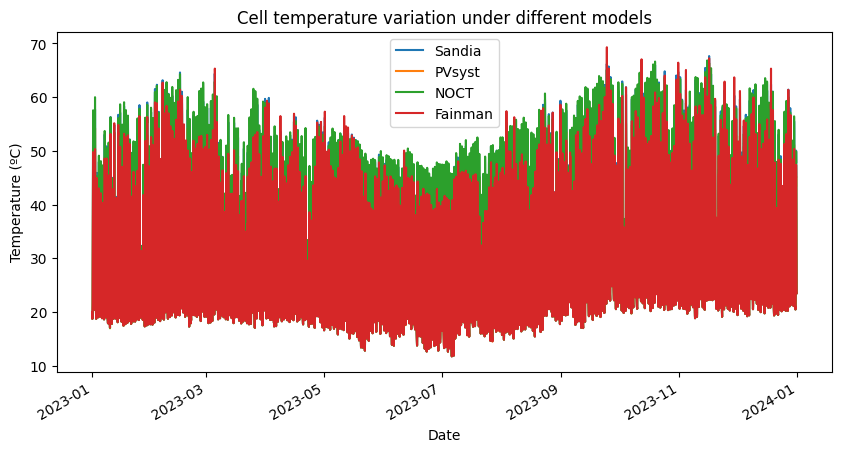

In [ ]:
#@title Calculating the cell temperature

df_pv_cell = pd.DataFrame()

df_pv_cell['Sandia'] = pvlib.temperature.sapm_cell(poa_global = df_poa['POA'], temp_air = df_data['temp_air'], wind_speed = df_data['wind_speed'], a = -3.47, b = -0.0594, deltaT = 3, irrad_ref=1000.0)
df_pv_cell['PVsyst'] = pvlib.temperature.pvsyst_cell(poa_global = df_poa['POA'], temp_air = df_data['temp_air'], wind_speed = df_data['wind_speed'], u_c = 29.0, u_v=0.0, module_efficiency=0.1701, alpha_absorption=0.9)
df_pv_cell['NOCT'] = pvlib.temperature.ross(poa_global = df_poa['POA'], temp_air = df_data['temp_air'], noct = 45)
df_pv_cell['Fainman'] = pvlib.temperature.faiman(poa_global = df_poa['POA'], temp_air = df_data['temp_air'], wind_speed= df_data['wind_speed'], u0=25.0, u1=6.84)
#df_pv_cell['Prilliman (smooth)'] = pvlib.temperature.prilliman(df_pv_cell['Fainman'], df_data['wind_speed'], unit_mass=11.1, coefficients=None)

df_pv_cell.plot(figsize=(10, 5), title='Cell temperature variation under different models')
plt.ylabel('Temperature (ºC)')
plt.xlabel('Date')
plt.show()





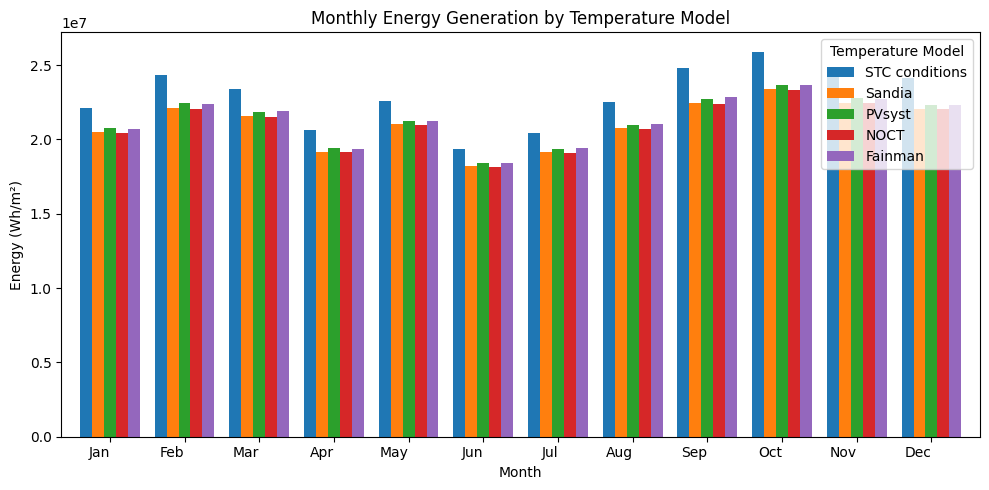

In [ ]:
#@title Comparing monthly energy generation

# Calculate the energy

df_enery_temp = pd.DataFrame()

for temp_model in df_pv_cell.columns:
    power = solve_desoto_params(df_poa['POA'], df_pv_cell[temp_model], a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)

    # Get the energy
    energy = power['Key_points']['p_mp']

    # Calculate the monthly energy
    df_monthly_energy[temp_model] = energy.resample('ME').sum()



# Plotting all columns in df_monthly_energy to compare the different temperature models
# df_monthly_energy.plot(figsize=(12, 6), title='Monthly Energy Generation by Temperature Model')
# plt.ylabel('Energy (Wh/m²/month)')
# plt.xlabel('Month')
# plt.legend(title='Temperature Model')
# plt.grid(True)
# plt.show()

df_monthly_energy.plot(kind='bar', figsize=(10, 5), width=0.8)
plt.title('Monthly Energy Generation by Temperature Model')
plt.ylabel('Energy (Wh/m²)')
plt.xlabel('Month')
#plt.xticks(rotation=45, ha='right')

# Get the month names from the index
month_names = df_monthly_energy.index.strftime('%b') # '%b' gives abbreviated month name

# Set the x-tick labels to the month names
plt.xticks(ticks=range(len(month_names)), labels=month_names, rotation=0, ha='right')


plt.legend(title='Temperature Model')
plt.tight_layout()
plt.show()

The previuos bar chart demonstrates the impact of cell temperature on PV energy generation. Each bar cluster represents monthly energy output in Wh/m², comparing predictions under Standard Test Conditions (STC) with four temperature models: Sandia, PVsyst, NOCT, and Faiman.

The blue bars (STC) consistently show the highest energy generation across all months. This reflects ideal lab conditions—25°C cell temperature and 1000 W/m² irradiance—which are rarely achieved in real-world environments. The other models account for temperature-induced losses, resulting in lower energy output than the STC benchmark. This confirms that higher cell temperatures reduce the conversion efficiency of PV modules, leading to diminished energy yield.

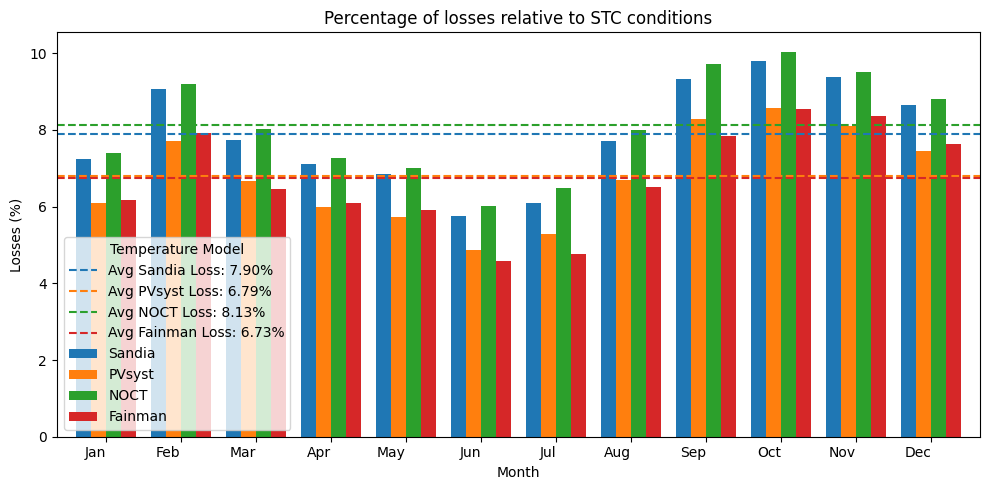

In [ ]:
#@title Percentage of monthly energy losses considering different cell temperature models relative to Standard Test Conditions (STC).

def analyze_solar_energy_loss(df_monthly_energy, reference_column='STC conditions',
                            figsize=(10, 5)):
    """
    Calculate and visualize monthly energy loss percentage relative to STC conditions.

    Parameters:
    -----------
    df_monthly_energy : pd.DataFrame
        DataFrame with monthly energy data for different temperature models.
        Index should be datetime (months) and columns should be temperature models.
    reference_column : str, default 'STC conditions'
        The reference column to calculate losses against.
    figsize : tuple, default (12, 6)
        Figure size for the plot (width, height).

    Returns:
    --------
    pd.DataFrame (optional)
        DataFrame with loss percentages if return_data=True.

    Raises:
    -------
    ValueError
        If reference_column is not found in the DataFrame columns.
    """

    # Validate input
    if reference_column not in df_monthly_energy.columns:
        raise ValueError(f"Reference column '{reference_column}' not found in DataFrame columns")

    # Calculate the loss by temperature relative to reference conditions
    df_monthly_loss_percentage = pd.DataFrame()

    for temp_model in df_monthly_energy.columns:
        if temp_model == reference_column:  # Skip reference column
            continue
        df_monthly_loss_percentage[temp_model] = (
            (df_monthly_energy[reference_column] - df_monthly_energy[temp_model]) /
            df_monthly_energy[reference_column] * 100
        )

    # Plot the loss percentage using bar plots
    ax = df_monthly_loss_percentage.plot(kind='bar', figsize=figsize, width=0.8)
    plt.title(f'Percentage of losses relative to STC conditions')
    plt.ylabel('Losses (%)')
    plt.xlabel('Month')

    # Get the month names from the index
    month_names = df_monthly_loss_percentage.index.strftime('%b')  # '%b' gives abbreviated month name

    # Set the x-tick labels to the month names
    plt.xticks(ticks=range(len(month_names)), labels=month_names, rotation=0, ha='right')

    # Add horizontal lines for the average loss for each temperature model
    bar_colors = [patch.get_facecolor() for patch in ax.patches]

    # Get the list of temperature models being plotted (excluding reference)
    temperature_models_for_plotting = [col for col in df_monthly_loss_percentage.columns
                                        if col != reference_column]

    # Get the unique colors
    unique_bar_colors = [bar_colors[i * len(df_monthly_loss_percentage.index)]
                        for i in range(len(temperature_models_for_plotting))]

    # Add average lines
    for i, temp_model in enumerate(temperature_models_for_plotting):
        average_loss = df_monthly_loss_percentage[temp_model].mean()
        # Use the color from the corresponding bar
        plt.axhline(y=average_loss, color=unique_bar_colors[i], linestyle='--',
                    label=f'Avg {temp_model} Loss: {average_loss:.2f}%')

    plt.legend(title='Temperature Model')
    plt.tight_layout()
    plt.show()

    return df_monthly_loss_percentage

# Run function
loss = analyze_solar_energy_loss(df_monthly_energy)

The monthly energy loss values due to temperature, relative to Standard Test Conditions (STC), highlight notable differences among the four temperature models available in pvlib: Sandia, PVsyst, NOCT, and Faiman. Over the course of the year, the NOCT model reports the highest average energy loss at 8.13%, followed closely by Sandia at 7.90%, while PVsyst and Faiman yield lower estimates of 6.79% and 6.73%, respectively. These results indicate that the PVsyst and Faiman models tend to produce more conservative (i.e., lower) estimates of thermal losses, potentially underestimating real-world performance degradation due to heat. In contrast, the Sandia model strikes a balance between detail and realism, incorporating key environmental factors such as irradiance, ambient temperature, and wind speed through empirically derived coefficients. This makes the Sandia model more suitable for accurate and robust energy yield assessments, particularly in climates with variable thermal conditions.

# 3. PV Plant Modeling Using the ClearSky Model

In this section, we use the Ineichen clear-sky model to estimate solar irradiance under cloudless conditions. This model provides a reliable representation of the theoretical maximum irradiance based on inputs such as time, geographic location, atmospheric pressure, and aerosol optical depth. Modeling the PV plant using clear-sky data offers a straightforward and efficient approach, especially in scenarios where measured irradiance data is unavailable.

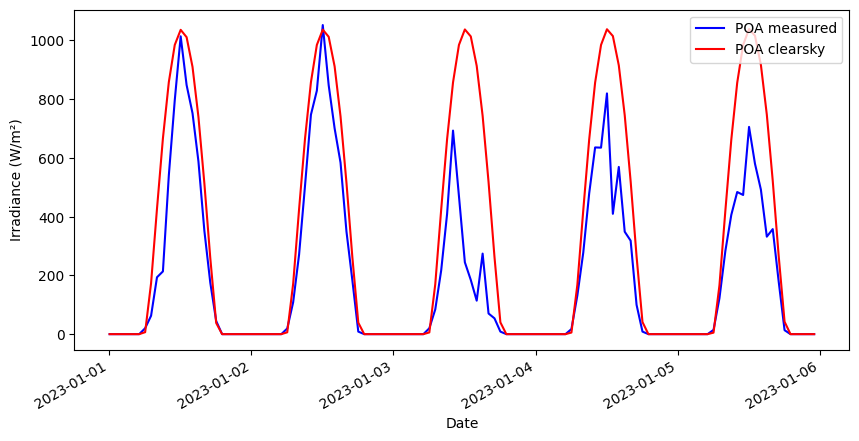

In [ ]:
#@title Calculate POA

# Clearsky components
df_clearsky = site_location.get_clearsky(df_data.index)

poa_clearsky = get_poa_irradiance(site_location,
                                  df_clearsky.index,
                                  df_clearsky['dni'],
                                  df_clearsky['ghi'],
                                  df_clearsky['dhi'],
                                  inclination,
                                  azimuth,
                                  model = "perez-driesse")

# Plot POA clearsky vs POA measured
plt.figure(figsize=(10, 5))
# Plot the data
df_poa['POA'].loc['2023-01-01':'2023-01-05'].plot(label = 'POA measured', color = 'blue')
poa_clearsky['POA'].loc['2023-01-01':'2023-01-05'].plot(label = 'POA clearsky', color = 'red')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Date')
plt.legend()
plt.show()

In the previous figure, the clear-sky POA irradiance (red line) forms a smooth and idealized curve, representing the maximum theoretical irradiance under cloudless sky conditions. Its symmetrical, bell-shaped profile reflects the typical daily solar cycle. In contrast, the measured POA irradiance (blue line) exhibits significant variability, primarily due to cloud cover, atmospheric disturbances, and transient weather events. These fluctuations directly impact energy generation. Under clear-sky conditions, the model assumes optimal irradiance, resulting in higher predicted energy output compared to actual measurements affected by real-world conditions.

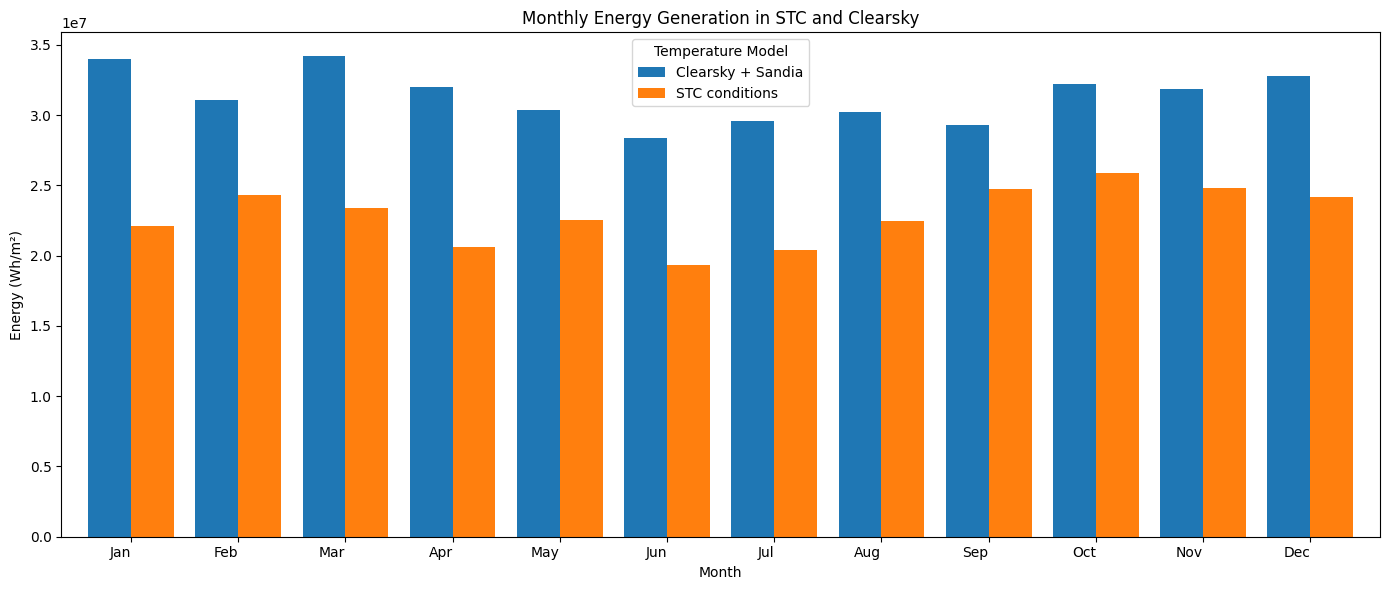

In [ ]:
#@title Calculate the energy generation

# Calculate the energy
df_energy_clearsky = pd.DataFrame()

# Use POA clearsky and sandia temperature model
power = solve_desoto_params(poa_clearsky['POA'], df_pv_cell['Sandia'], a_ref, I_L_ref, I_o_ref, R_sh_ref, R_s, method, number_of_points)
# Get the energy
energy = power['Key_points']['p_mp']
# Add to the dataframe
df_energy_clearsky['Clearsky + Sandia'] = energy.resample('ME').sum()

# Add monthly energy in STC conditions
df_energy_clearsky['STC conditions'] = df_monthly_energy['STC conditions']


# Plot the data
# df_energy_clearsky.plot(figsize=(12, 6), title='Monthly Energy Generation by Temperature Model')
# plt.ylabel('Energy (Wh/m²/month)')
# plt.xlabel('Month')
# plt.legend(title='Temperature Model')
# plt.grid(True)
# plt.show()

# Bar plot
df_energy_clearsky.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Monthly Energy Generation in STC and Clearsky')
plt.ylabel('Energy (Wh/m²)')
plt.xlabel('Month')
#plt.xticks(rotation=45, ha='right')

# Get the month names from the index
month_names = df_energy_clearsky.index.strftime('%b') # '%b' gives abbreviated month name

# Set the x-tick labels to the month names
plt.xticks(ticks=range(len(month_names)), labels=month_names, rotation=0, ha='right')


plt.legend(title='Temperature Model')
plt.tight_layout()
plt.show()

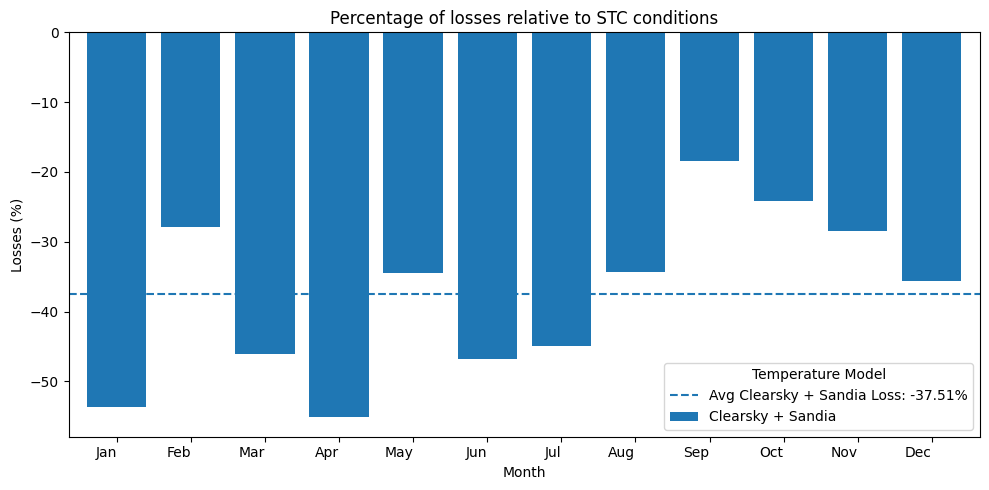

In [ ]:
#@title Percentage of monthly losses relative to STC conditions.

loss = analyze_solar_energy_loss(df_energy_clearsky)

Although the energy generated under the Clearsky + Sandia model is higher in absolute terms than under STC conditions (as shown in the figure), the percentage loss is calculated relative to STC as the baseline. Consequently, the loss values appear negative, indicating an increase in performance compared to the measure data scenario. This outcome is expected, as the Clearsky model assumes optimal irradiance conditions.

This analysis shows that energy generation under optimal irradiance conditions, such as those modeled by clear-sky scenarios, can be significantly higher than values based on measured data, which reflect real-world weather variability. These findings highlight the importance of incorporating environmental factors—especially temperature effects—into PV modeling to achieve accurate performance estimates. This is particularly critical in hot climates, where temperature-induced efficiency losses can be substantial.

While relying solely on clear-sky models may overestimate actual energy yield, they remain a valuable tool when on-site data is unavailable. In such cases, clear-sky modeling enables comparative assessments of PV performance across different geographic regions, independent of short-term weather fluctuations.

# 4. Invert clipping losses

Inverter clipping losses occur in PV system when the DC power output from the solar panels exceeds the maximum AC power capacity of the inverter. Since the inverter is limited in how much power it can convert and export to the grid, any excess DC energy produced during peak sunlight hours is "clipped," meaning it is not utilized and is effectively lost. These losses are most prominent in systems where the DC/AC ratio (also known as the inverter loading ratio) is greater than 1. While clipping reduces the total energy yield during high irradiance periods, it is often an intentional design choice: oversizing the PV array relative to the inverter can increase the overall annual energy production and improve the economics of the system.


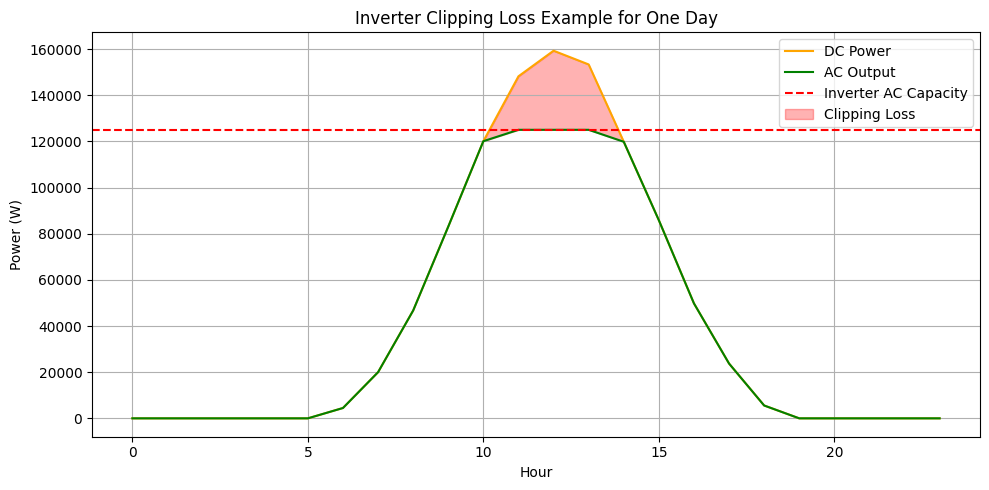

In [ ]:
#@title Show clipping loss

def plot_clipping(df_power, ac_capacity):
    # Filter a one day of df dataframe
    dc_power = df_power.loc['2023-12-15':'2023-12-15']

    # Calculate clipped AC output and clipping losses
    ac_output = np.minimum(dc_power, ac_capacity)
    clipping_loss = dc_power - ac_output

    # Create a DataFrame
    df = pd.DataFrame({
        'Hour': dc_power.index.hour,
        'DC Power (kW)': dc_power,
        'AC Output (kW)': ac_output,
        'Clipping Loss (kW)': clipping_loss
    })
    df.set_index('Hour', inplace=True)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['DC Power (kW)'], label='DC Power', color='orange')
    plt.plot(df.index, df['AC Output (kW)'], label='AC Output', color='green')
    plt.axhline(ac_capacity, color='red', linestyle='--', label='Inverter AC Capacity')

    # Fill clipping loss area
    plt.fill_between(df.index, df['AC Output (kW)'], df['DC Power (kW)'],
                    where=df['DC Power (kW)'] > ac_capacity,
                    interpolate=True, color='red', alpha=0.3, label='Clipping Loss')

    plt.title('Inverter Clipping Loss Example for One Day')
    plt.xlabel('Hour')
    plt.ylabel('Power (W)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_clipping(df_power['STC conditions'], ac_capacity=125000)


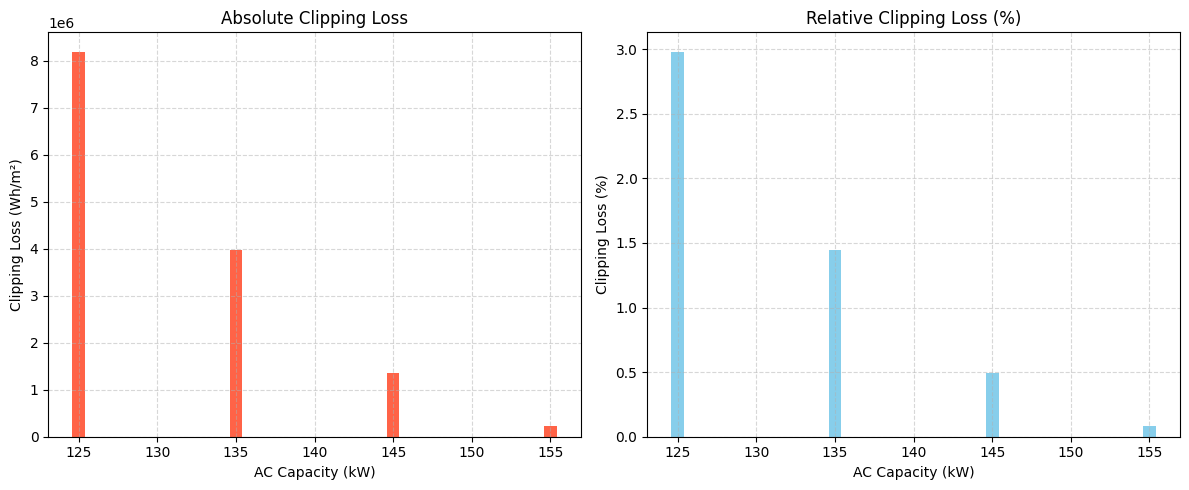

In [ ]:
#@title Calculating clipping loss (check the units in Y axis is KW or W?)
def plot_clipping_results(results_df):
    """
    Plot clipping losses (kWh and %) from the results DataFrame.

    Parameters:
    - results_df (pd.DataFrame): Output from calculate_clipping_losses function.
    """
    capacities = results_df['AC Capacity (kW)'] / 1000

    # Plot absolute clipping loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.bar(capacities, results_df['Clipping Loss (kWh)'], color='tomato')
    plt.title('Absolute Clipping Loss')
    plt.xlabel('AC Capacity (kW)')
    plt.ylabel('Clipping Loss (Wh/m²)')
    plt.grid(True, linestyle='--', alpha=0.5)

    # Plot relative clipping loss (%)
    plt.subplot(1, 2, 2)
    plt.bar(capacities, results_df['Clipping Loss (%)'], color='skyblue')
    plt.title('Relative Clipping Loss (%)')
    plt.xlabel('AC Capacity (kW)')
    plt.ylabel('Clipping Loss (%)')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def calculate_clipping_losses(dc_power_series, ac_capacities):
    """
    Calculate annual inverter clipping losses for different AC capacities.

    Parameters:
    - dc_power_series (pd.Series): Hourly DC power data (in kW), indexed by datetime.
    - ac_capacities (list or array): List of AC capacities (in kW) to evaluate.

    Returns:
    - pd.DataFrame: DataFrame with total energy (kWh), clipped energy (kWh), and clipping loss (%) for each capacity.
    """
    results = []

    for ac_cap in ac_capacities:
        ac_output = np.minimum(dc_power_series, ac_cap)
        clipping_loss = dc_power_series - ac_output

        total_dc_energy = dc_power_series.sum()
        total_ac_energy = ac_output.sum()
        total_clipping = clipping_loss.sum()
        loss_percent = 100 * total_clipping / total_dc_energy if total_dc_energy > 0 else 0

        results.append({
            'AC Capacity (kW)': ac_cap,
            'Total DC Energy (kWh)': total_dc_energy,
            'Total AC Energy (kWh)': total_ac_energy,
            'Clipping Loss (kWh)': total_clipping,
            'Clipping Loss (%)': loss_percent
        })

    return pd.DataFrame(results)


# Define a list of inverter capacities (in kW)
ac_capacities = [125000, 135000, 145000, 155000]

# Run the function
clipping_results = calculate_clipping_losses(df_power['STC conditions'], ac_capacities)
plot_clipping_results(clipping_results)

The analysis of clipping losses for different inverter capacities shows that a 125 kW inverter results in an annual energy loss of approximately 2.98% due to clipping. While increasing the inverter capacity to 135 kW, 145 kW, and 155 kW reduces the clipping losses to 1.45%, 0.49%, and 0.09% respectively, the incremental energy gains become progressively smaller. The choice of a 125 kW inverter represents a balanced trade-off between system performance and economic efficiency. This design decision accepts a modest energy loss in exchange for lower equipment costs and improved inverter utilization throughout the year, aligning with common industry practices that favor a higher DC/AC ratio to optimize overall system economics.